In [ ]:
import pandas as pd
import plotly.express as px

caminho = '/content/drive/MyDrive/Ciência de Dados/Dados/datatran2026.csv'
detran = pd.read_csv(caminho, encoding='latin-1', sep=';')

/tmp/ipykernel_2715/444134623.py:5: DtypeWarning:

Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.



Previsão de notas para 6 horas: 78.19
R² (Qualidade): 0.99
RMSE (Caso extremo): 2.51


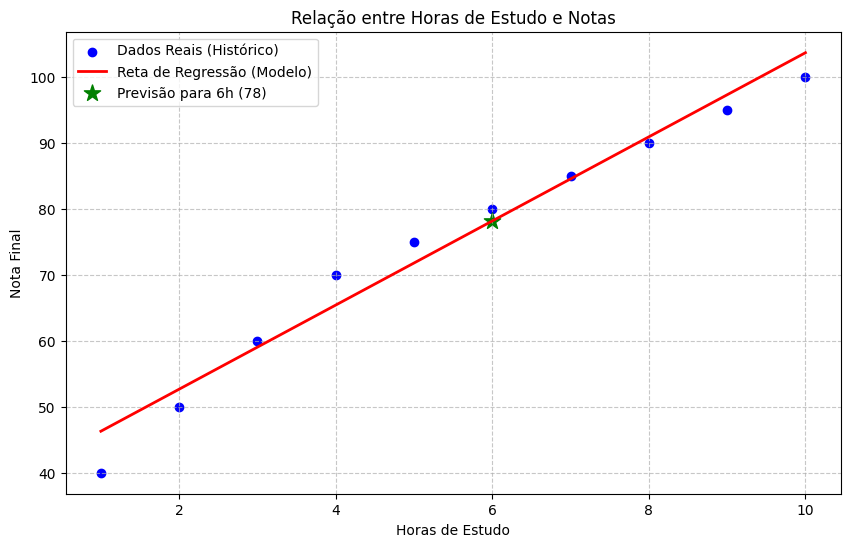

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

x_horas = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y_notas = np.array([40, 50, 60, 70, 75, 80, 85, 90, 95, 100])

modelo_notas = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(x_horas, y_notas, test_size=0.2, random_state=42)

modelo_notas.fit(X_train, y_train)

y_pred = modelo_notas.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

horas_futuras = [[6]]
previsao_notas = modelo_notas.predict(horas_futuras)

print(f"Previsão de notas para 6 horas: {previsao_notas[0]:.2f}")
print(f"R² (Qualidade): {r2:.2f}")
print(f"RMSE (Caso extremo): {rmse:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(x_horas, y_notas, color='blue', label='Dados Reais (Histórico)')

reta_predicao = modelo_notas.predict(x_horas)
plt.plot(x_horas, reta_predicao, color='red', linewidth=2, label='Reta de Regressão (Modelo)')

plt.scatter(6, previsao_notas, color='green', s=150, marker='*', label=f'Previsão para 6h ({previsao_notas[0]:.0f})')

plt.title('Relação entre Horas de Estudo e Notas')
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota Final')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

R² (Qualidade): 0.18
RMSE (Caso extremo): 1.95
MAE (Média de erro): 0.96
Previsão para 6 veículos: 6.03


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



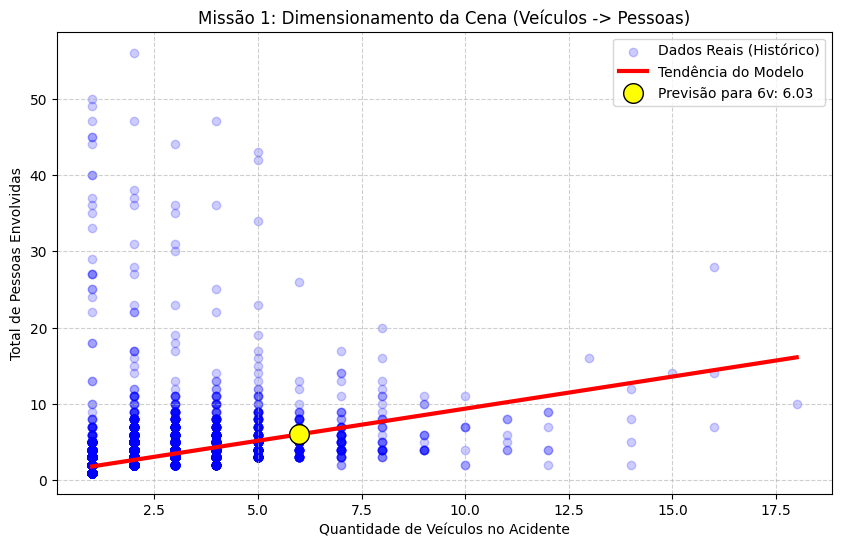

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

#Exercicio 1
df = detran.dropna(subset=['veiculos', 'pessoas'])
X = df[['veiculos']]
y = df['pessoas']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_split = LinearRegression()
modelo_split.fit(X_train, y_train)

previsoes_teste = modelo_split.predict(X_test)

r2 = r2_score(y_test, previsoes_teste)
mse = mean_squared_error(y_test, previsoes_teste)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, previsoes_teste)

print(f"R² (Qualidade): {r2:.2f}")
print(f"RMSE (Caso extremo): {rmse:.2f}")
print(f"MAE (Média de erro): {mae:.2f}")

prev_6 = modelo_split.predict(np.array([[6]]))[0]
print(f"Previsão para 6 veículos: {prev_6:.2f}")

plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='blue', alpha=0.2, label='Dados Reais (Histórico)')

X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(X_range, modelo_split.predict(X_range), color='red', linewidth=3, label='Tendência do Modelo')

plt.scatter(6, prev_6, color='yellow', s=200, edgecolors='black', marker='o', zorder=5, label=f'Previsão para 6v: {prev_6:.2f}')

plt.title('Missão 1: Dimensionamento da Cena (Veículos -> Pessoas)')
plt.xlabel('Quantidade de Veículos no Acidente')
plt.ylabel('Total de Pessoas Envolvidas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

R² (Qualidade): 0.34
RMSE (Caso extremo): 1.20
MAE (Média de erro): 0.65
Previsão para 10 pessoas: 5.76 ilesas


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



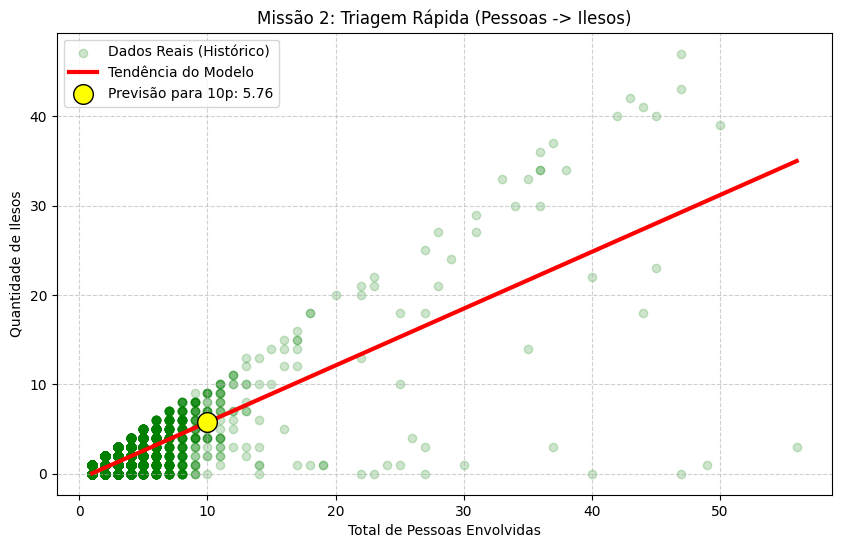

In [ ]:
# Exercício 2:
df2 = detran.dropna(subset=['pessoas', 'ilesos'])
X2 = df2[['pessoas']]
y2 = df2['ilesos']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

modelo2 = LinearRegression()
modelo2.fit(X2_train, y2_train)

previsoes2 = modelo2.predict(X2_test)
r2_2 = r2_score(y2_test, previsoes2)
rmse_2 = np.sqrt(mean_squared_error(y2_test, previsoes2))
mae_2 = mean_absolute_error(y2_test, previsoes2)

print(f"R² (Qualidade): {r2_2:.2f}")
print(f"RMSE (Caso extremo): {rmse_2:.2f}")
print(f"MAE (Média de erro): {mae_2:.2f}")

prev_10 = modelo2.predict(np.array([[10]]))[0]
print(f"Previsão para 10 pessoas: {prev_10:.2f} ilesas")

plt.figure(figsize=(10, 6))

plt.scatter(X2, y2, color='green', alpha=0.2, label='Dados Reais (Histórico)')

X2_range = np.linspace(X2.min(), X2.max(), 100).reshape(-1, 1)
plt.plot(X2_range, modelo2.predict(X2_range), color='red', linewidth=3, label='Tendência do Modelo')

plt.scatter(10, prev_10, color='yellow', s=200, edgecolors='black', marker='o', zorder=5, label=f'Previsão para 10p: {prev_10:.2f}')

plt.title('Missão 2: Triagem Rápida (Pessoas -> Ilesos)')
plt.xlabel('Total de Pessoas Envolvidas')
plt.ylabel('Quantidade de Ilesos')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

R² (Qualidade): 0.10
RMSE (Caso extremo): 0.61
MAE (Média de erro): 0.40
Previsão para 5 feridos: 1.34 graves


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



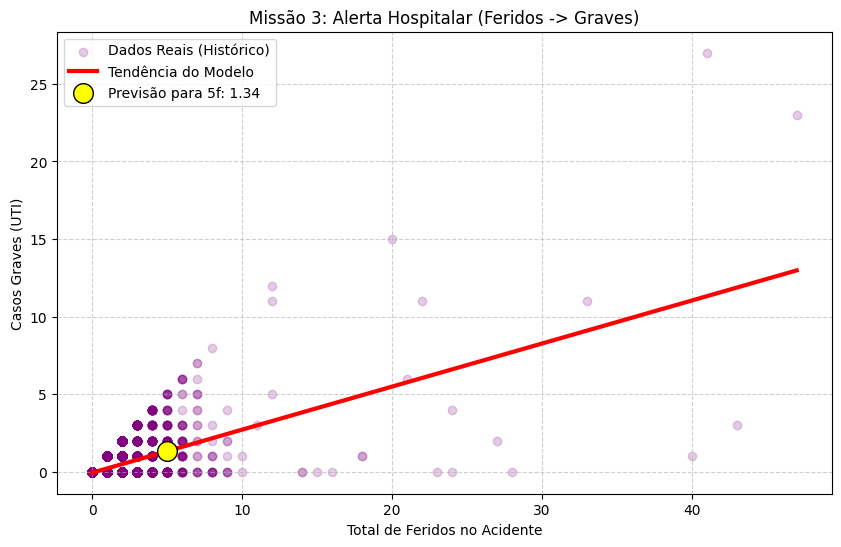

In [ ]:
# Exercício 3
df3 = detran.dropna(subset=['feridos', 'feridos_graves'])
X3 = df3[['feridos']]
y3 = df3['feridos_graves']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

modelo3 = LinearRegression()
modelo3.fit(X3_train, y3_train)

previsoes3 = modelo3.predict(X3_test)
r2_3 = r2_score(y3_test, previsoes3)
rmse_3 = np.sqrt(mean_squared_error(y3_test, previsoes3))
mae_3 = mean_absolute_error(y3_test, previsoes3)

print(f"R² (Qualidade): {r2_3:.2f}")
print(f"RMSE (Caso extremo): {rmse_3:.2f}")
print(f"MAE (Média de erro): {mae_3:.2f}")

prev_5_feridos = modelo3.predict(np.array([[5]]))[0]
print(f"Previsão para 5 feridos: {prev_5_feridos:.2f} graves")

plt.figure(figsize=(10, 6))

plt.scatter(X3, y3, color='purple', alpha=0.2, label='Dados Reais (Histórico)')

X3_range = np.linspace(X3.min(), X3.max(), 100).reshape(-1, 1)
plt.plot(X3_range, modelo3.predict(X3_range), color='red', linewidth=3, label='Tendência do Modelo')

plt.scatter(5, prev_5_feridos, color='yellow', s=200, edgecolors='black', marker='o', zorder=5, label=f'Previsão para 5f: {prev_5_feridos:.2f}')

plt.title('Missão 3: Alerta Hospitalar (Feridos -> Graves)')
plt.xlabel('Total de Feridos no Acidente')
plt.ylabel('Casos Graves (UTI)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

R²: 0.77
MSE: 510.87


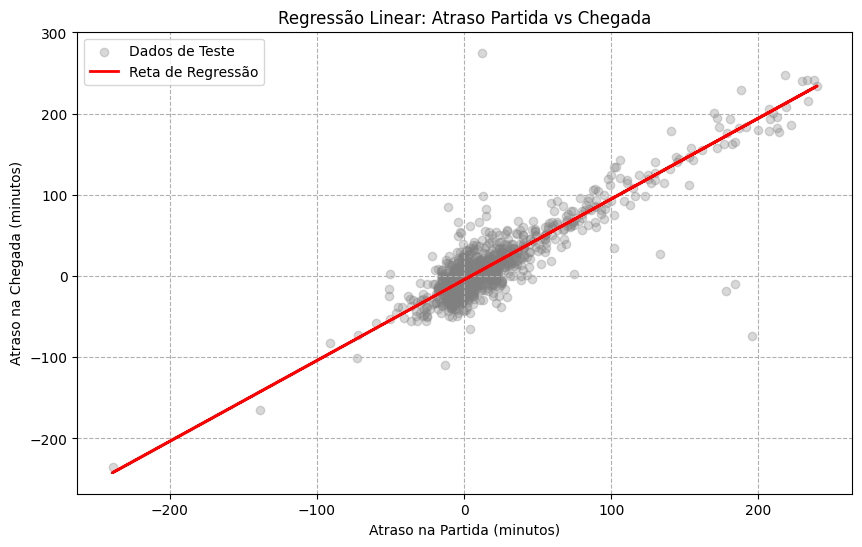

In [ ]:
# Exercício 4
df_aviacao = pd.read_csv('/content/drive/MyDrive/Ciência de Dados/Dados/AVIACAO.csv', sep=';', skiprows=1, encoding='latin-1')

cols_dt = ['Partida Prevista', 'Partida Real', 'Chegada Prevista', 'Chegada Real']
for col in cols_dt:
    df_aviacao[col] = pd.to_datetime(df_aviacao[col], errors='coerce')

df_aviacao['Atraso_Partida'] = (df_aviacao['Partida Real'] - df_aviacao['Partida Prevista']).dt.total_seconds() / 60
df_aviacao['Atraso_Chegada'] = (df_aviacao['Chegada Real'] - df_aviacao['Chegada Prevista']).dt.total_seconds() / 60

df_limpo = df_aviacao.dropna(subset=['Atraso_Partida', 'Atraso_Chegada'])

X = df_limpo[['Atraso_Partida']]
y = df_limpo['Atraso_Chegada']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_voo = LinearRegression()
modelo_voo.fit(X_train, y_train)

y_pred = modelo_voo.predict(X_test)

print(f"R²: {r2_score(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.3, color='gray', label='Dados de Teste')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Reta de Regressão')
plt.title('Regressão Linear: Atraso Partida vs Chegada')
plt.xlabel('Atraso na Partida (minutos)')
plt.ylabel('Atraso na Chegada (minutos)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

In [ ]:
# Exercício 5
X = df_limpo[['Atraso_Partida']]
y = df_limpo['Atraso_Chegada']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_aviacao = LinearRegression()
modelo_aviacao.fit(X_train, y_train)

y_pred = modelo_aviacao.predict(X_test)

r2_aviacao = r2_score(y_test, y_pred)
mse_aviacao = mean_squared_error(y_test, y_pred)

print(f"R² (Coeficiente de Determinação): {r2_aviacao:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse_aviacao:.2f}")

R² (Coeficiente de Determinação): 0.7707
MSE (Erro Quadrático Médio): 510.87


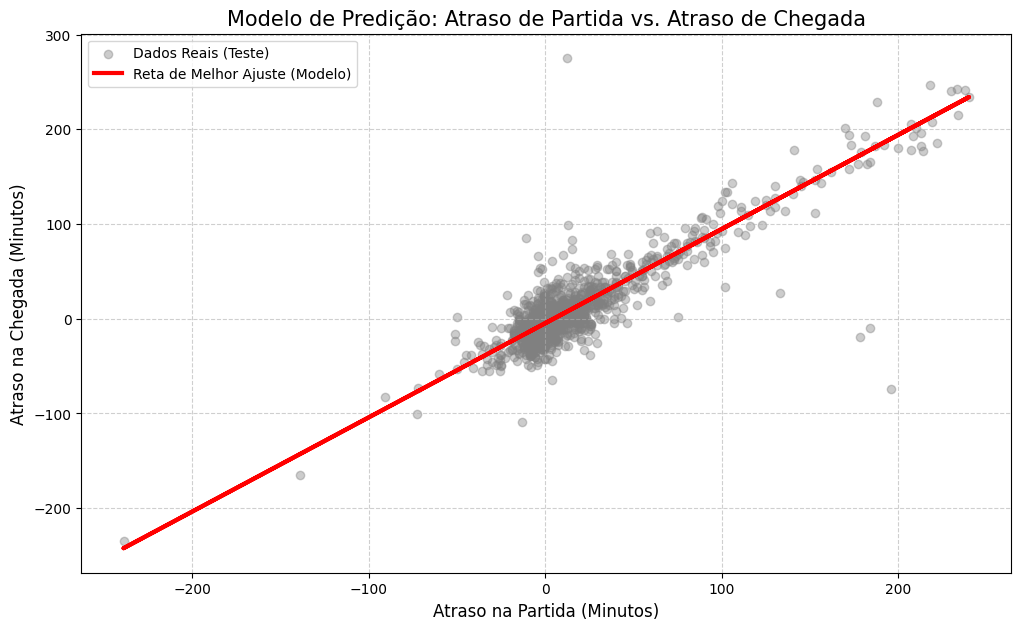

In [ ]:
# Exercício 6
plt.figure(figsize=(12, 7))

plt.scatter(X_test, y_test, color='gray', alpha=0.4, label='Dados Reais (Teste)')

plt.plot(X_test, y_pred, color='red', linewidth=3, label='Reta de Melhor Ajuste (Modelo)')

plt.title('Modelo de Predição: Atraso de Partida vs. Atraso de Chegada', fontsize=15)
plt.xlabel('Atraso na Partida (Minutos)', fontsize=12)
plt.ylabel('Atraso na Chegada (Minutos)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()